<h1>Anti Money Laundering Detection System</h1>

The Data is generated by a generator at IBM considering real life examples. These virtual transactions serve the purpose of training the model and detect laundering as the real world tranactions cannot be used for privacy and ethical reasons  

In [1]:
!pip install pyspark

<h2>Imports Section</h2>

In [3]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, TimestampType
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
import numpy as np
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.sql.functions import col, count, when, lag, lit, unix_timestamp, to_timestamp, dayofmonth, expr
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from sklearn.model_selection import train_test_split
from pyspark.sql.window import Window
from sklearn.metrics import roc_curve, auc

<h2>I. Data Collection</h2>

In [4]:
spark = SparkSession.builder\
.appName("Anti Money Laundering Detection System")\
.config("spark.executor.memory", "6g")\
.config("spark.driver.memory", "6g")\
.config("spark.sql.shuffle.partitions", "200") \
.getOrCreate()

In [5]:
schema = StructType([
    StructField("Timestamp", StringType(), True),
    StructField("From Bank", IntegerType(), True),
    StructField("From Bank Hex_Code", StringType(), True),
    StructField("To Bank", IntegerType(), True),
    StructField("To Bank Hex_Code", StringType(), True),
    StructField("Amount Received", DoubleType(), True),
    StructField("Receiving Currency", StringType(), True),
    StructField("Amount Paid", DoubleType(), True),
    StructField("Payment Currency", StringType(), True),
    StructField("Payment Format", StringType(), True),
    StructField("Is Laundering", IntegerType(), True)
])

In [6]:
data = spark.read.schema(schema)\
.option('header','True')\
.option("timestampFormat", "yyyy/MM/dd HH:mm")\
.csv("HI-Medium_Trans.csv")

<h2>II. a) Data Preprocessing</h2>

In [7]:
data.printSchema()

root
 |-- Timestamp: string (nullable = true)
 |-- From Bank: integer (nullable = true)
 |-- From Bank Hex_Code: string (nullable = true)
 |-- To Bank: integer (nullable = true)
 |-- To Bank Hex_Code: string (nullable = true)
 |-- Amount Received: double (nullable = true)
 |-- Receiving Currency: string (nullable = true)
 |-- Amount Paid: double (nullable = true)
 |-- Payment Currency: string (nullable = true)
 |-- Payment Format: string (nullable = true)
 |-- Is Laundering: integer (nullable = true)



In [8]:
data.show(5)

+----------------+---------+------------------+-------+----------------+---------------+------------------+-----------+----------------+--------------+-------------+
|       Timestamp|From Bank|From Bank Hex_Code|To Bank|To Bank Hex_Code|Amount Received|Receiving Currency|Amount Paid|Payment Currency|Payment Format|Is Laundering|
+----------------+---------+------------------+-------+----------------+---------------+------------------+-----------+----------------+--------------+-------------+
|2022/09/01 00:17|       20|         800104D70|     20|       800104D70|        6794.63|         US Dollar|    6794.63|       US Dollar|  Reinvestment|            0|
|2022/09/01 00:02|     3196|         800107150|   3196|       800107150|        7739.29|         US Dollar|    7739.29|       US Dollar|  Reinvestment|            0|
|2022/09/01 00:17|     1208|         80010E430|   1208|       80010E430|        1880.23|         US Dollar|    1880.23|       US Dollar|  Reinvestment|            0|
|202

In [9]:
data.describe().show()

+-------+----------------+-----------------+------------------+------------------+----------------+--------------------+------------------+--------------------+-----------------+--------------+--------------------+
|summary|       Timestamp|        From Bank|From Bank Hex_Code|           To Bank|To Bank Hex_Code|     Amount Received|Receiving Currency|         Amount Paid| Payment Currency|Payment Format|       Is Laundering|
+-------+----------------+-----------------+------------------+------------------+----------------+--------------------+------------------+--------------------+-----------------+--------------+--------------------+
|  count|        31898238|         31898238|          31898238|          31898238|        31898238|            31898238|          31898238|            31898238|         31898238|      31898238|            31898238|
|   mean|            NULL|294409.4462990714|          Infinity|409319.75427216385|        Infinity|    6431116.01001477|              NULL| 

In [10]:
null_counts = data.select([count(when(col(c).isNull(), c)).alias(c) for c in data.columns])
null_counts.show()

+---------+---------+------------------+-------+----------------+---------------+------------------+-----------+----------------+--------------+-------------+
|Timestamp|From Bank|From Bank Hex_Code|To Bank|To Bank Hex_Code|Amount Received|Receiving Currency|Amount Paid|Payment Currency|Payment Format|Is Laundering|
+---------+---------+------------------+-------+----------------+---------------+------------------+-----------+----------------+--------------+-------------+
|        0|        0|                 0|      0|               0|              0|                 0|          0|               0|             0|            0|
+---------+---------+------------------+-------+----------------+---------------+------------------+-----------+----------------+--------------+-------------+



<h2>II. b) Feature Engineering</h2>

In [15]:
data_copy = data.select("*")

In [ ]:
data_cleaned = data_cleaned.withColumn("Timestamp", col("Timestamp").cast("timestamp"))

windowSpec = Window.partitionBy("To Bank").orderBy("Timestamp")

data_with_prev = data_cleaned.withColumn("Prev_Timestamp", lag("Timestamp").over(windowSpec))

data_with_duration = data_with_prev.withColumn("Transaction_Duration", 
                       (unix_timestamp(col("Timestamp")) - unix_timestamp(col("Prev_Timestamp"))))

data_with_duration.select("To Bank", "Timestamp", "Prev_Timestamp", "Transaction_Duration").show(5)

In [18]:
windowSpec = Window.partitionBy("To Bank").orderBy("Timestamp")
data_copy = data_copy.withColumn("Prev_Timestamp", lag("Timestamp").over(windowSpec))
data_copy = data_copy.withColumn("Transaction_Duration", 
                       (unix_timestamp(col("Timestamp")) - unix_timestamp(col("Prev_Timestamp"))))
data_copy.select("To Bank", "Timestamp", "Prev_Timestamp", "Transaction_Duration").show(5)

+-------+----------------+----------------+--------------------+
|To Bank|       Timestamp|  Prev_Timestamp|Transaction_Duration|
+-------+----------------+----------------+--------------------+
|     28|2022/09/01 00:00|            NULL|                NULL|
|     28|2022/09/01 00:00|2022/09/01 00:00|                NULL|
|     28|2022/09/01 00:00|2022/09/01 00:00|                NULL|
|     28|2022/09/01 00:00|2022/09/01 00:00|                NULL|
|     28|2022/09/01 00:00|2022/09/01 00:00|                NULL|
+-------+----------------+----------------+--------------------+
only showing top 5 rows



In [21]:
transaction_type_count = data.groupBy("To Bank", "Payment Format").count()

+-------+--------------+-----+
|To Bank|Payment Format|count|
+-------+--------------+-----+
|   2310|        Cheque|12267|
|  25932|  Reinvestment|  885|
|   8882|   Credit Card| 4061|
|  32675|  Reinvestment|   15|
| 169746|   Credit Card| 1418|
+-------+--------------+-----+
only showing top 5 rows



In [17]:
data_copy = data_copy.withColumn("Amount_Ratio", col("Amount Paid") / col("Amount Received"))

transaction_counts = data_copy.groupBy("From Bank").count().withColumnRenamed("count", "Transaction_Frequency")
data_copy = data_copy.join(transaction_counts, on="From Bank", how="left")

data_copy = data_copy.fillna({"Transaction_Duration": 0})

<h2>II. Exploratory Data Analysis (EDA) </h2>

In [38]:
Laundering = data[data['Is Laundering']==1]
Non_Laundering = data[data['Is Laundering']==0]
laundering_count = data.filter(data["Is Laundering"] == 1).count()
non_laundering_count = data.filter(data["Is Laundering"] == 0).count()
print("Number of Laundering cases:", laundering_count)
print("Number of Non-Laundering cases:", non_laundering_count)
data.groupBy('Is Laundering').count().show()

Number of Laundering cases: 35230
Number of Non-Laundering cases: 31863008
+-------------+--------+
|Is Laundering|   count|
+-------------+--------+
|            1|   35230|
|            0|31863008|
+-------------+--------+



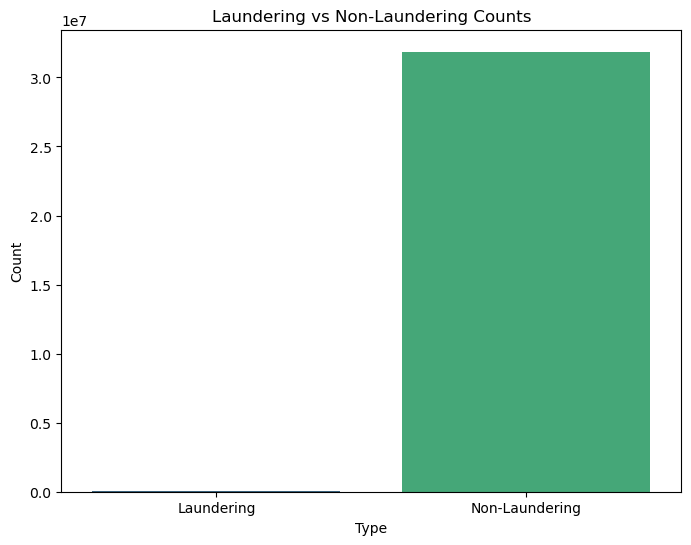

In [13]:
counts = {
    "Type": ["Laundering", "Non-Laundering"],
    "Count": [laundering_count, non_laundering_count]
}
counts_df = pd.DataFrame(counts)
plt.figure(figsize=(8, 6))
sns.barplot(x="Type", y="Count", data=counts_df, palette="viridis")
plt.title("Laundering vs Non-Laundering Counts")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

The laundering cases are very low compared to the non laundering cases. But as we train a model, we try to include all the laundered transactions for the model to identify the patterns and increase the performance. Also, training on ~32 million rows is both time and resource consuming. Hence, during training, we can sample the data and train.

In [45]:
transaction_counts = Laundering.groupBy('Payment Currency').agg(F.count('*').alias('Transaction Count'))
transaction_counts.show()

+-----------------+-----------------+
| Payment Currency|Transaction Count|
+-----------------+-----------------+
|              Yen|             1114|
|Australian Dollar|              737|
|      Saudi Riyal|              224|
|           Shekel|              658|
|             Yuan|             2775|
|  Canadian Dollar|              605|
|             Euro|             9710|
|      Swiss Franc|              330|
|        US Dollar|            14292|
|      Brazil Real|              279|
|          Bitcoin|              244|
|            Ruble|             1457|
|         UK Pound|             1629|
|     Mexican Peso|              346|
|            Rupee|              830|
+-----------------+-----------------+



In [16]:
receiving_currency_counts = data.groupBy('Receiving Currency').count()
receiving_currency_counts.show()

+------------------+--------+
|Receiving Currency|   count|
+------------------+--------+
|               Yen|  860154|
|          UK Pound| 1020042|
| Australian Dollar|  931364|
|       Saudi Riyal|  572750|
|      Mexican Peso|  852272|
|            Shekel| 1428622|
|              Yuan| 2295849|
|   Canadian Dollar| 1089398|
|              Euro| 7329170|
|             Rupee|  741594|
|       Swiss Franc|  856680|
|         US Dollar|11594241|
|       Brazil Real|  638411|
|           Bitcoin|  698372|
|             Ruble|  989319|
+------------------+--------+



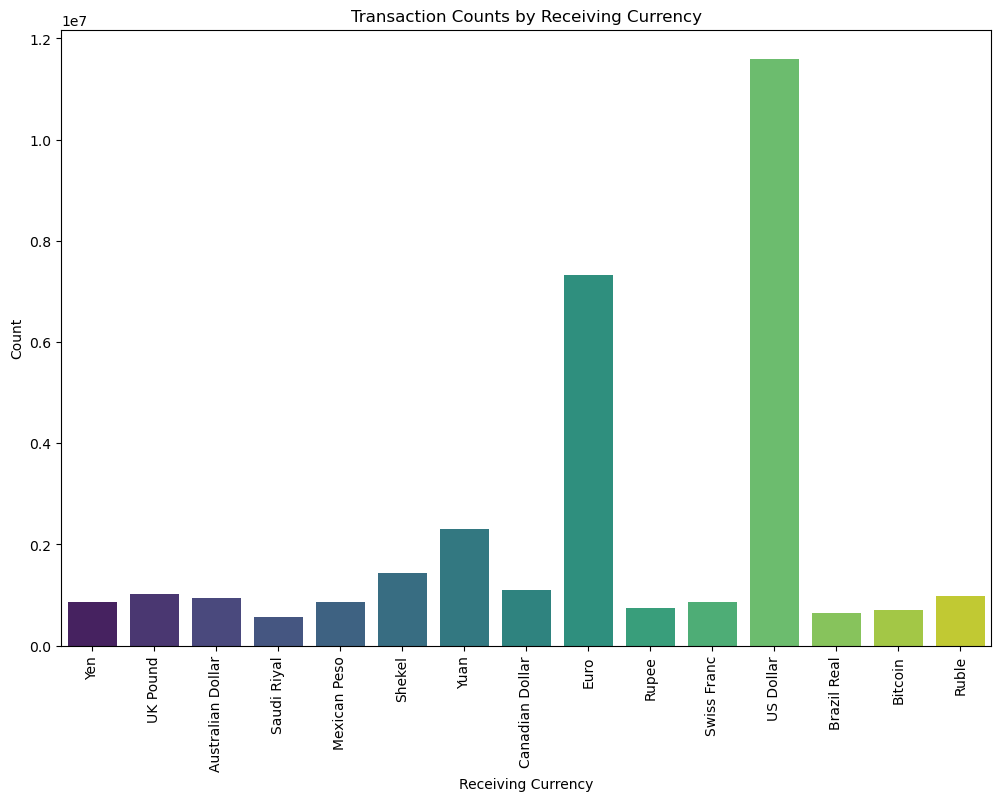

In [17]:
receiving_currency_counts_pd = receiving_currency_counts.toPandas()
plt.figure(figsize=(12, 8))
sns.barplot(x="Receiving Currency", y="count", data=receiving_currency_counts_pd, palette="viridis")
plt.title("Transaction Counts by Receiving Currency")
plt.xlabel("Receiving Currency")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [18]:
payment_currency_counts = data.groupBy('Payment Currency').count()
payment_currency_counts.show()

+-----------------+--------+
| Payment Currency|   count|
+-----------------+--------+
|              Yen|  856132|
|         UK Pound| 1018575|
|Australian Dollar|  918569|
|      Saudi Riyal|  564505|
|     Mexican Peso|  841257|
|           Shekel| 1408707|
|             Yuan| 2330638|
|  Canadian Dollar| 1078358|
|             Euro| 7315958|
|            Rupee|  738718|
|      Swiss Franc|  844623|
|        US Dollar|11688249|
|      Brazil Real|  629510|
|          Bitcoin|  688914|
|            Ruble|  975525|
+-----------------+--------+



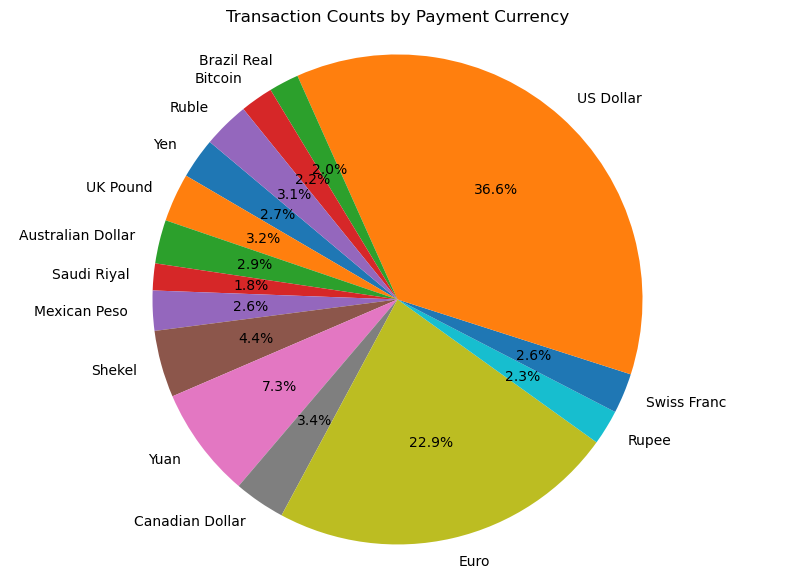

In [19]:
payment_currency_counts_pd = payment_currency_counts.toPandas()

plt.figure(figsize=(10, 7))
plt.pie(payment_currency_counts_pd['count'], labels=payment_currency_counts_pd['Payment Currency'], autopct='%1.1f%%', startangle=140)
plt.title("Transaction Counts by Payment Currency")
plt.axis('equal')
plt.show()

In [21]:
diff_currency_trans = data.filter(data['Receiving Currency'] != data['Payment Currency'])
inter_currency_counts = diff_currency_trans.groupBy('Receiving Currency', 'Payment Currency').count()
inter_currency_counts.show()

+------------------+-----------------+-----+
|Receiving Currency| Payment Currency|count|
+------------------+-----------------+-----+
|           Bitcoin|     Mexican Peso|   18|
|   Canadian Dollar|            Rupee|  236|
|   Canadian Dollar|      Swiss Franc|   10|
|              Euro|      Brazil Real|  203|
|          UK Pound|      Brazil Real|    9|
|       Saudi Riyal|            Rupee|  197|
|         US Dollar|      Saudi Riyal|  107|
|            Shekel|      Brazil Real|   61|
|       Swiss Franc|             Euro| 1286|
|      Mexican Peso|Australian Dollar|   45|
|      Mexican Peso|           Shekel|   14|
|            Shekel|  Canadian Dollar|  290|
|             Ruble|              Yen|  446|
|              Yuan|Australian Dollar|   65|
|               Yen|        US Dollar|10965|
|         US Dollar|            Ruble| 1132|
|               Yen|            Rupee|   71|
|             Rupee|     Mexican Peso|   10|
|               Yen|         UK Pound|  103|
|       Sa

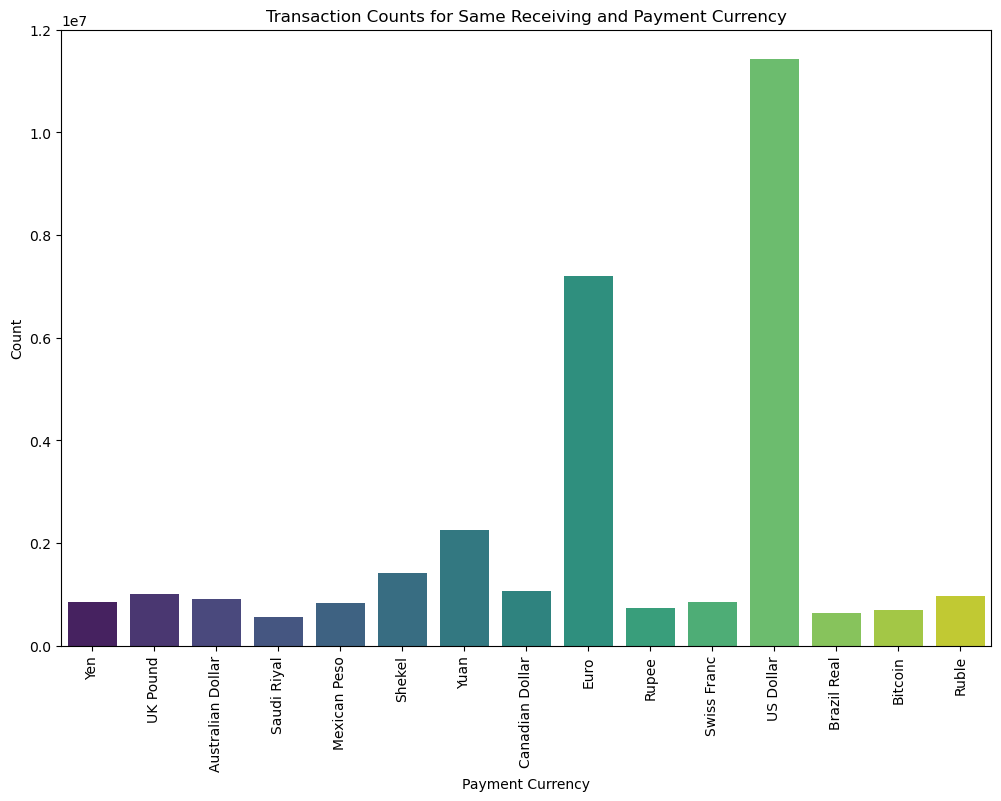

In [22]:
same_currency_counts_pd = same_currency_counts.toPandas()

plt.figure(figsize=(12, 8))
sns.barplot(x="Payment Currency", y="count", data=same_currency_counts_pd, palette="viridis")
plt.title("Transaction Counts for Same Receiving and Payment Currency")
plt.xlabel("Payment Currency")
plt.ylabel("Count")
plt.xticks(rotation=90) 
plt.show()

In [23]:
same_currency_trans = data.filter(data['Receiving Currency'] == data['Payment Currency'])
same_currency_counts = same_currency_trans.groupBy('Payment Currency').count()
same_currency_counts.show()

+-----------------+--------+
| Payment Currency|   count|
+-----------------+--------+
|              Yen|  845439|
|         UK Pound| 1003299|
|Australian Dollar|  916834|
|      Saudi Riyal|  564196|
|     Mexican Peso|  838922|
|           Shekel| 1407929|
|             Yuan| 2258494|
|  Canadian Dollar| 1072557|
|             Euro| 7210831|
|            Rupee|  730221|
|      Swiss Franc|  843096|
|        US Dollar|11430671|
|      Brazil Real|  628744|
|          Bitcoin|  688694|
|            Ruble|  973167|
+-----------------+--------+



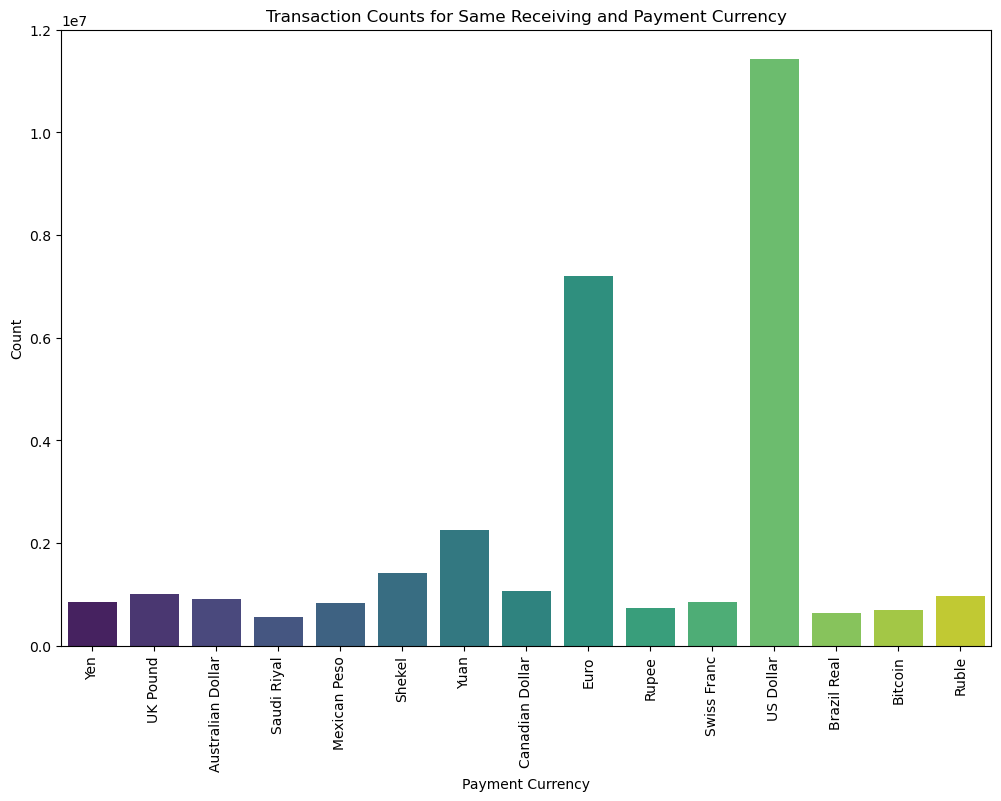

In [24]:
same_currency_counts_pd = same_currency_counts.toPandas()

plt.figure(figsize=(12, 8))
sns.barplot(x="Payment Currency", y="count", data=same_currency_counts_pd, palette="viridis")
plt.title("Transaction Counts for Same Receiving and Payment Currency")
plt.xlabel("Payment Currency")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [25]:
same_curr = data.filter(col('Receiving Currency') == col('Payment Currency'))
cross_curr = data.filter(col('Receiving Currency') != col('Payment Currency'))

same_curr_count = same_curr.count()
cross_curr_count = cross_curr.count()

print("Number of transactions with the same currency:", same_curr_count)
print("Number of transactions with different currencies:", cross_curr_count)

Number of transactions with the same currency: 31413094
Number of transactions with different currencies: 485144


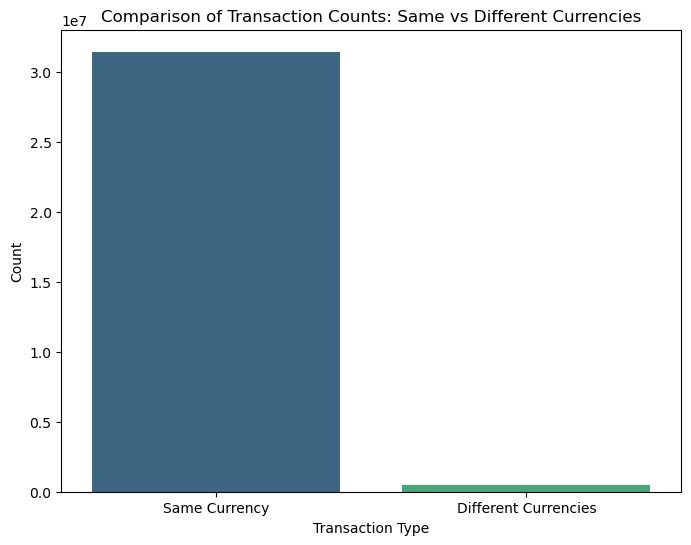

In [26]:
currency_comparison_counts = {
    "Transaction Type": ["Same Currency", "Different Currencies"],
    "Count": [same_curr_count, cross_curr_count]
}
currency_comparison_counts_df = pd.DataFrame(currency_comparison_counts)

plt.figure(figsize=(8, 6))
sns.barplot(x="Transaction Type", y="Count", data=currency_comparison_counts_df, palette="viridis")
plt.title("Comparison of Transaction Counts: Same vs Different Currencies")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

In [31]:
amount_received_counts = data.groupBy('Receiving Currency').count()
amount_received_counts.show()

+------------------+--------+
|Receiving Currency|   count|
+------------------+--------+
|               Yen|  860154|
|          UK Pound| 1020042|
| Australian Dollar|  931364|
|       Saudi Riyal|  572750|
|      Mexican Peso|  852272|
|            Shekel| 1428622|
|              Yuan| 2295849|
|   Canadian Dollar| 1089398|
|              Euro| 7329170|
|             Rupee|  741594|
|       Swiss Franc|  856680|
|         US Dollar|11594241|
|       Brazil Real|  638411|
|           Bitcoin|  698372|
|             Ruble|  989319|
+------------------+--------+



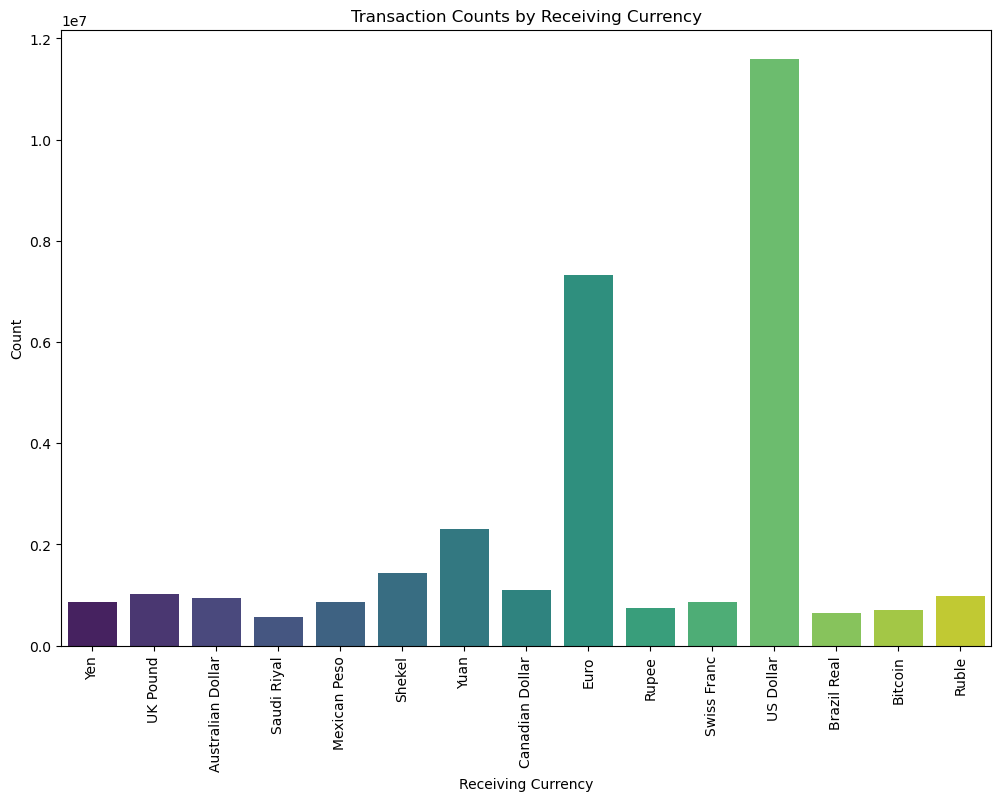

In [36]:
amount_received_counts_pd = amount_received_counts.toPandas()
plt.figure(figsize=(12, 8))
sns.barplot(x="Receiving Currency", y="count", data=amount_received_counts_pd, palette="viridis")
plt.title("Transaction Counts by Receiving Currency")
plt.xlabel("Receiving Currency")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [34]:
amount_paid_counts = data.groupBy('Payment Currency').count()
amount_paid_counts.show()

+-----------------+--------+
| Payment Currency|   count|
+-----------------+--------+
|              Yen|  856132|
|         UK Pound| 1018575|
|Australian Dollar|  918569|
|      Saudi Riyal|  564505|
|     Mexican Peso|  841257|
|           Shekel| 1408707|
|             Yuan| 2330638|
|  Canadian Dollar| 1078358|
|             Euro| 7315958|
|            Rupee|  738718|
|      Swiss Franc|  844623|
|        US Dollar|11688249|
|      Brazil Real|  629510|
|          Bitcoin|  688914|
|            Ruble|  975525|
+-----------------+--------+



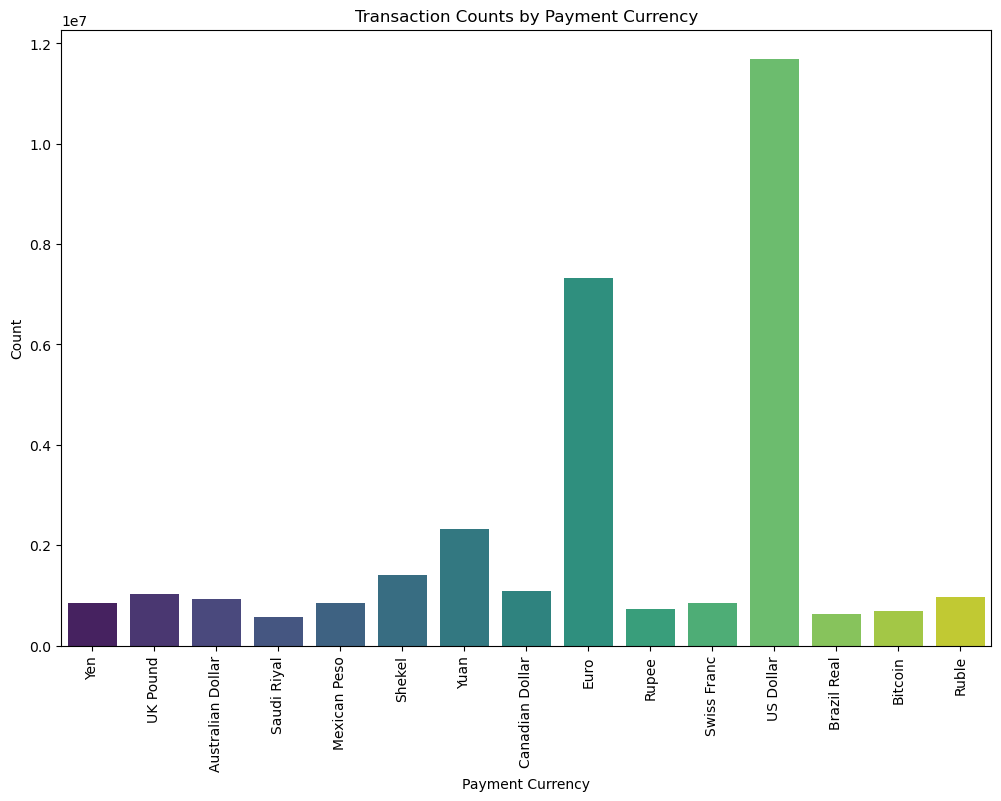

In [35]:
amount_paid_counts_pd = amount_paid_counts.toPandas()
plt.figure(figsize=(12, 8))
sns.barplot(x="Payment Currency", y="count", data=amount_paid_counts_pd, palette="viridis")
plt.title("Transaction Counts by Payment Currency")
plt.xlabel("Payment Currency")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [40]:
category_counts = data.groupBy("Payment Format").count()
category_counts.show()

+--------------+--------+
|Payment Format|   count|
+--------------+--------+
|           ACH| 3868410|
|   Credit Card| 8777816|
|  Reinvestment| 1945611|
|        Cheque|12280058|
|          Cash| 3217531|
|          Wire| 1119774|
|       Bitcoin|  689038|
+--------------+--------+



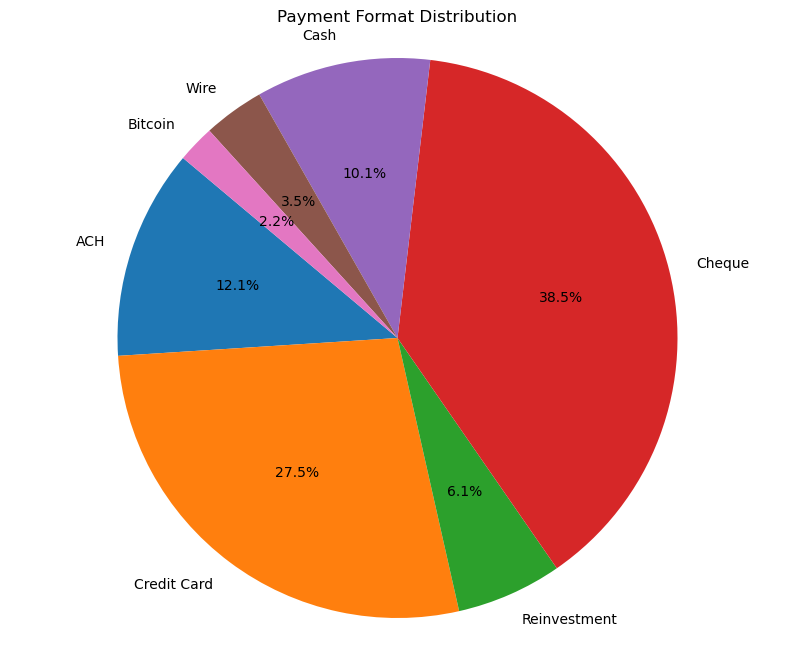

In [41]:
category_counts_pd = category_counts.toPandas()

plt.figure(figsize=(10, 8))
plt.pie(category_counts_pd['count'], labels=category_counts_pd['Payment Format'], autopct='%1.1f%%', startangle=140)
plt.title('Payment Format Distribution')
plt.axis('equal') 
plt.show()

In [37]:
data = data.withColumn("Amount Received", col("Amount Received").cast("double"))
data = data.withColumn("Amount Paid", col("Amount Paid").cast("double"))
data = data.withColumn("From Bank", col("From Bank").cast("int"))
data = data.withColumn("To Bank", col("To Bank").cast("int"))
data = data.withColumn("Is Laundering", col("Is Laundering").cast("int"))

numeric_features = ["From Bank", "To Bank", "Amount Received", "Amount Paid", "Is Laundering"]
numeric_data = data.select(numeric_features)

correlation_matrix = numeric_data.toPandas().corr()
print(correlation_matrix)

                 From Bank   To Bank  Amount Received  Amount Paid  \
From Bank         1.000000  0.356241        -0.000704    -0.000610   
To Bank           0.356241  1.000000        -0.000946    -0.000781   
Amount Received  -0.000704 -0.000946         1.000000     0.721340   
Amount Paid      -0.000610 -0.000781         0.721340     1.000000   
Is Laundering    -0.007243 -0.010197         0.000599     0.000876   

                 Is Laundering  
From Bank            -0.007243  
To Bank              -0.010197  
Amount Received       0.000599  
Amount Paid           0.000876  
Is Laundering         1.000000  


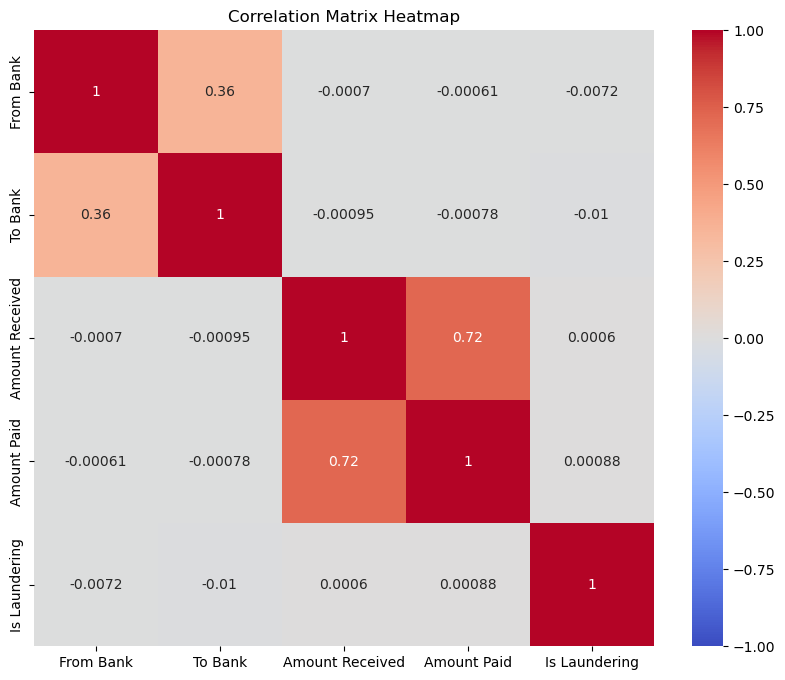

In [39]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix Heatmap')
plt.show()

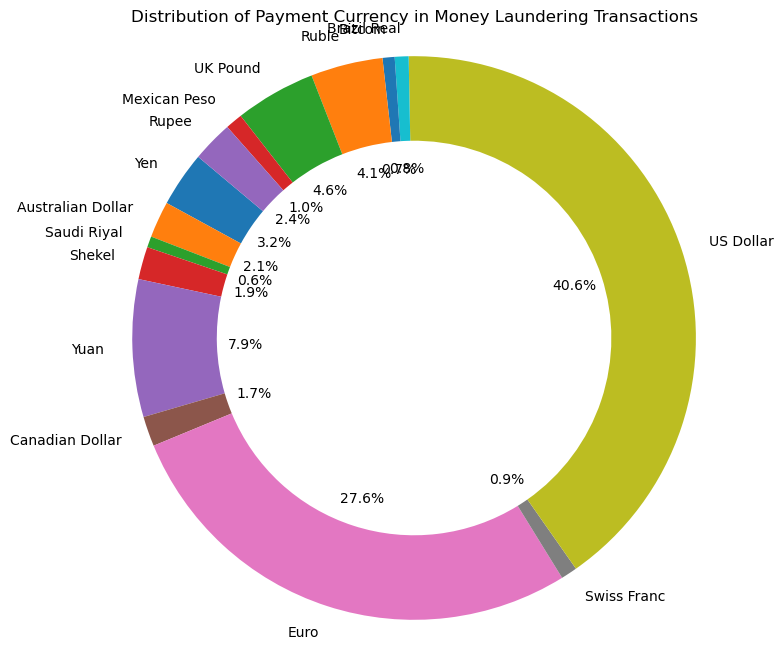

In [46]:
transaction_counts_pd = transaction_counts.toPandas()
plt.figure(figsize=(8, 8))
plt.pie(transaction_counts_pd['Transaction Count'], labels=transaction_counts_pd['Payment Currency'], autopct='%1.1f%%', startangle=140, wedgeprops=dict(width=0.3))
plt.title('Distribution of Payment Currency in Money Laundering Transactions')
plt.axis('equal')  
plt.show()

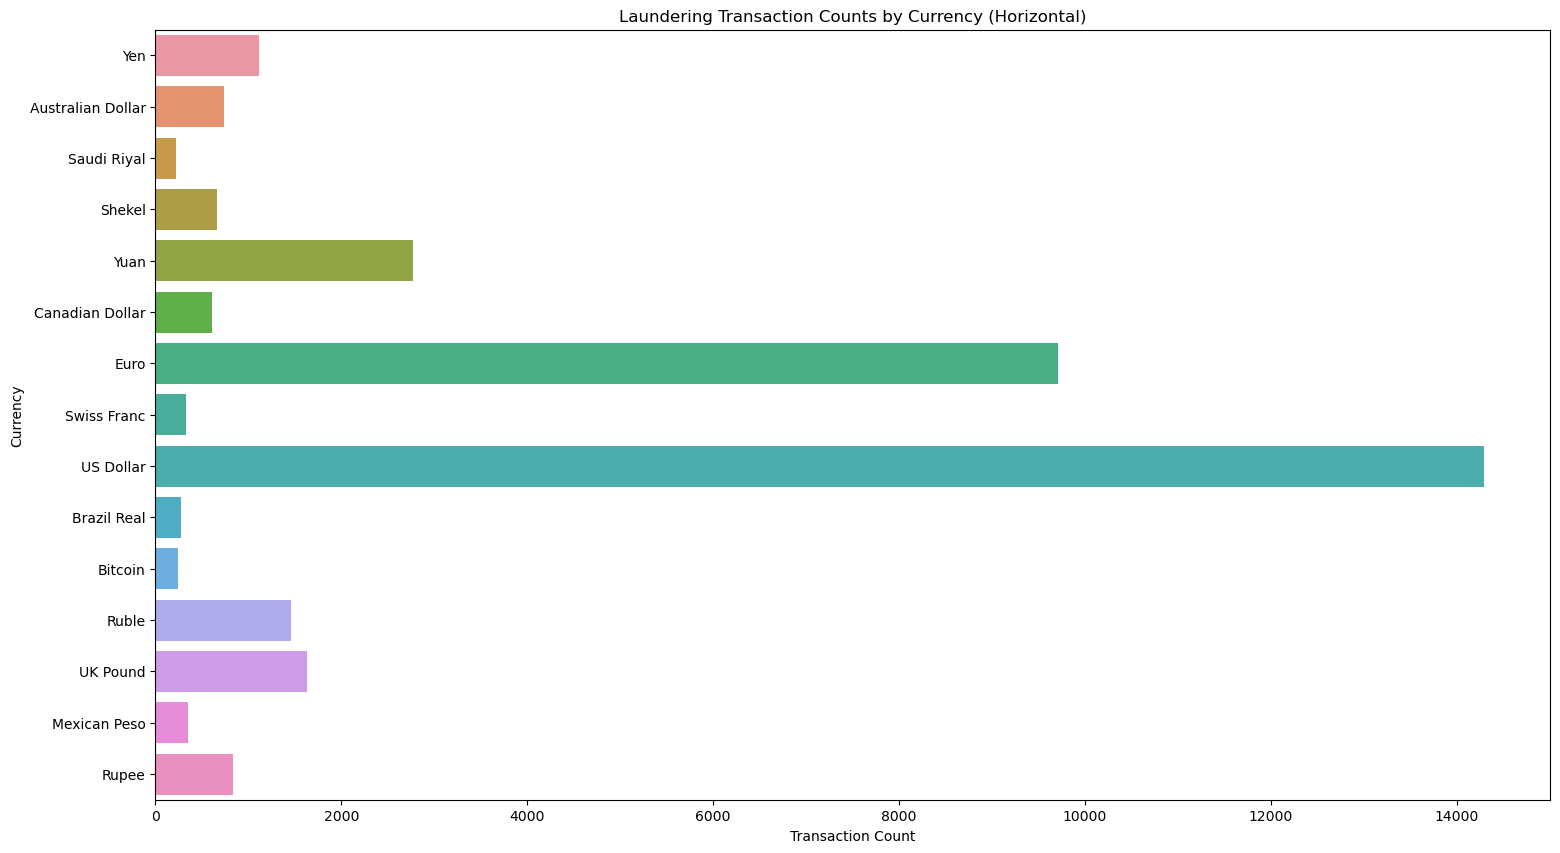

In [47]:
plt.figure(figsize=(18, 10))
sns.barplot(x='Transaction Count', y='Payment Currency', data=transaction_counts_pd, orient='h')
plt.title('Laundering Transaction Counts by Currency (Horizontal)')
plt.xlabel('Transaction Count')
plt.ylabel('Currency')
plt.show()

In [49]:
payment_format_counts = Laundering.groupBy("Payment Format").count().withColumnRenamed("count", "Transaction Count")
payment_format_counts.show()

+--------------+-----------------+
|Payment Format|Transaction Count|
+--------------+-----------------+
|           ACH|            30746|
|   Credit Card|             1354|
|        Cheque|             2220|
|          Cash|              666|
|       Bitcoin|              244|
+--------------+-----------------+



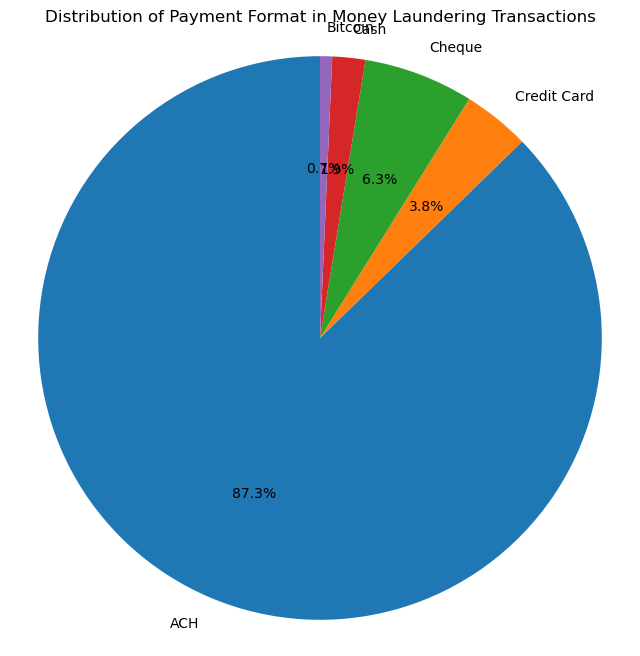

In [51]:
payment_format_pd = payment_format_counts.toPandas()
plt.figure(figsize=(8, 8))  
plt.pie(payment_format_pd['Transaction Count'], labels=payment_format_pd['Payment Format'], autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Payment Format in Money Laundering Transactions')
plt.axis('equal')  
plt.show()

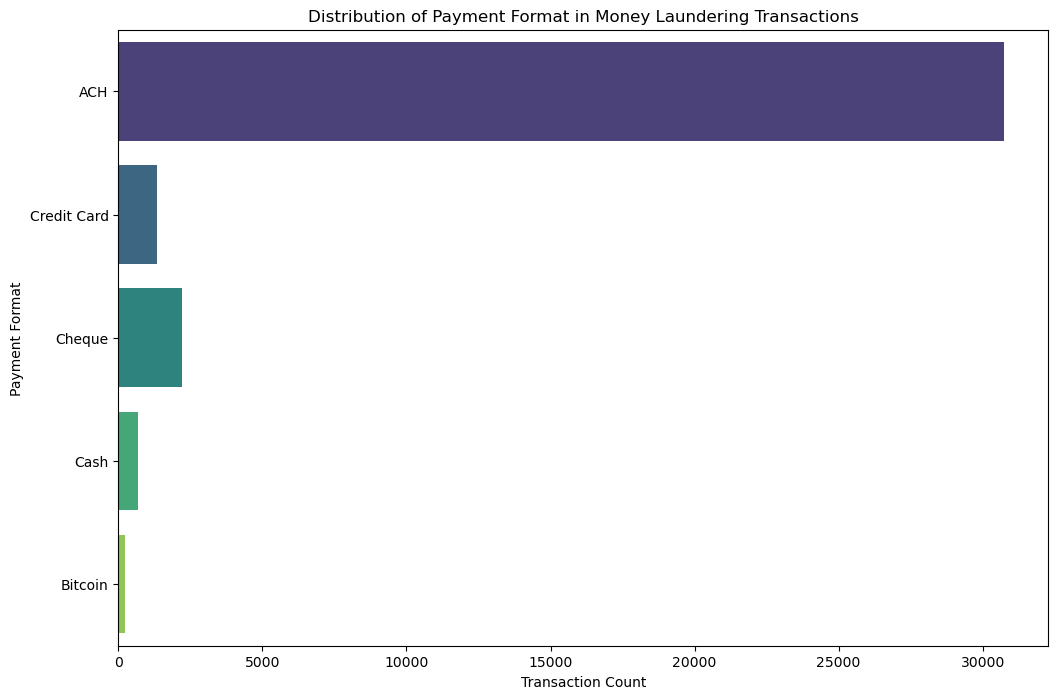

In [53]:
plt.figure(figsize=(12, 8))
sns.barplot(x='Transaction Count', y='Payment Format', data=payment_format_pd, palette='viridis')
plt.title('Distribution of Payment Format in Money Laundering Transactions')
plt.xlabel('Transaction Count')
plt.ylabel('Payment Format')
plt.show()

<h4>Laundering Transactions over a period of time</h4>

In [55]:
Laundering = Laundering.withColumn("Timestamp", to_timestamp("Timestamp", 'yyyy/MM/dd HH:mm'))
Laundering = Laundering.withColumn("Day", dayofmonth("Timestamp"))

In [56]:
daily_transactions = Laundering.groupBy("Day").count().orderBy("Day")
daily_transactions.show()

+---+-----+
|Day|count|
+---+-----+
|  1| 1056|
|  2| 1331|
|  3| 1373|
|  4| 1549|
|  5| 1863|
|  6| 2041|
|  7| 2147|
|  8| 2154|
|  9| 2199|
| 10| 2081|
| 11| 1966|
| 12| 2179|
| 13| 2275|
| 14| 2263|
| 15| 2253|
| 16| 2416|
| 17| 1199|
| 18|  916|
| 19|  695|
| 20|  492|
+---+-----+
only showing top 20 rows



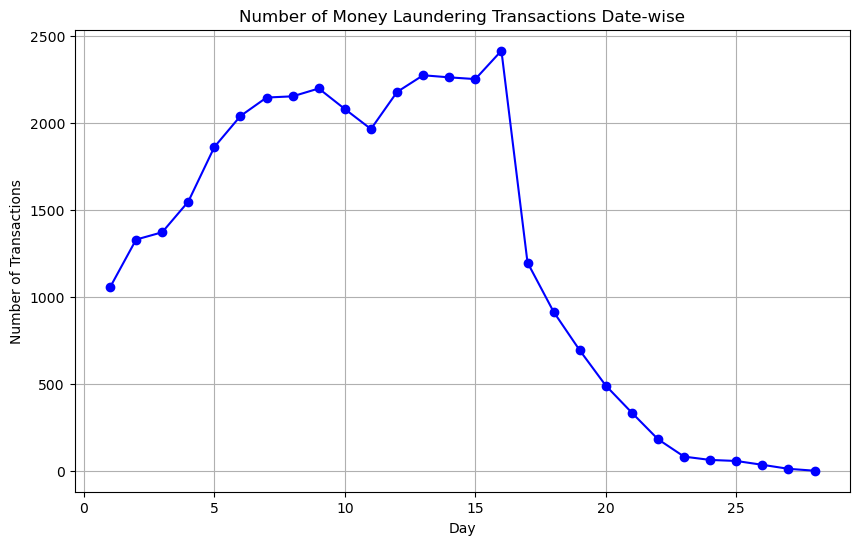

In [57]:
daily_transactions_pd = daily_transactions.toPandas()
plt.figure(figsize=(10, 6))
plt.plot(daily_transactions_pd['Day'], daily_transactions_pd['count'], marker='o', color='b')
plt.title('Number of Money Laundering Transactions Date-wise')
plt.xlabel('Day')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

<h2>III. Feature Engineering</h2>

In [19]:
categoricalColumns = ['Receiving Currency', 'Payment Currency', 'Payment Format']
stages = []

for categoricalCol in categoricalColumns:
    stringIndexer = StringIndexer(inputCol=categoricalCol, outputCol=categoricalCol + 'Index')
    encoder = OneHotEncoder(inputCols=[stringIndexer.getOutputCol()], outputCols=[categoricalCol + 'classVec'])
    stages += [stringIndexer, encoder]

numeric_features = ["From Bank", "To Bank", "Amount Received", "Amount Paid"]

assemblerInputs = [c + "classVec" for c in categoricalColumns] + numeric_features
assembler = VectorAssembler(inputCols=assemblerInputs, outputCol="features")
stages += [assembler]

scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=False)
stages += [scaler]

pipeline = Pipeline(stages=stages)
transformed_df = pipeline.fit(data).transform(data)

transformed_df.show(5)

+----------------+---------+------------------+-------+----------------+---------------+------------------+-----------+----------------+--------------+-------------+-----------------------+--------------------------+---------------------+------------------------+-------------------+----------------------+--------------------+--------------------+
|       Timestamp|From Bank|From Bank Hex_Code|To Bank|To Bank Hex_Code|Amount Received|Receiving Currency|Amount Paid|Payment Currency|Payment Format|Is Laundering|Receiving CurrencyIndex|Receiving CurrencyclassVec|Payment CurrencyIndex|Payment CurrencyclassVec|Payment FormatIndex|Payment FormatclassVec|            features|      scaledFeatures|
+----------------+---------+------------------+-------+----------------+---------------+------------------+-----------+----------------+--------------+-------------+-----------------------+--------------------------+---------------------+------------------------+-------------------+-------------------

<h2>IV. Model Building for Laundering Detection</h2>

<h3>1. Logistic Regression</h3>

In [20]:
train_data, test_data = transformed_df.randomSplit([0.3, 0.7], seed=42)

In [21]:
lr = LogisticRegression(featuresCol='features', labelCol='Is Laundering', maxIter=10)

lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

<h4>Evaluation of Logistic Regression</h4>

In [66]:
evaluator = BinaryClassificationEvaluator(labelCol='Is Laundering', metricName='areaUnderROC')
roc_auc = evaluator.evaluate(lr_predictions)
print(f"ROC AUC: {roc_auc}")

evaluator_accuracy = MulticlassClassificationEvaluator(labelCol='Is Laundering', metricName='accuracy')
evaluator_precision = MulticlassClassificationEvaluator(labelCol='Is Laundering', metricName='weightedPrecision')
evaluator_recall = MulticlassClassificationEvaluator(labelCol='Is Laundering', metricName='weightedRecall')
evaluator_f1 = MulticlassClassificationEvaluator(labelCol='Is Laundering', metricName='f1')

accuracy = evaluator_accuracy.evaluate(predictions)
precision = evaluator_precision.evaluate(predictions)
recall = evaluator_recall.evaluate(predictions)
f1_score = evaluator_f1.evaluate(predictions)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")

ROC AUC: 0.5
Accuracy: 0.9988991193456477
Precision: 0.9977994506295105
Recall: 0.9988991193456477
F1 Score: 0.998348982169892


In [23]:
predictions_and_labels = lr_predictions.select('probability', 'Is Laundering').collect()

prob_positive = [row['probability'][1] for row in predictions_and_labels]
labels = [row['Is Laundering'] for row in predictions_and_labels]

In [24]:
fpr, tpr, thresholds = roc_curve(labels, prob_positive)
roc_auc = auc(fpr, tpr)

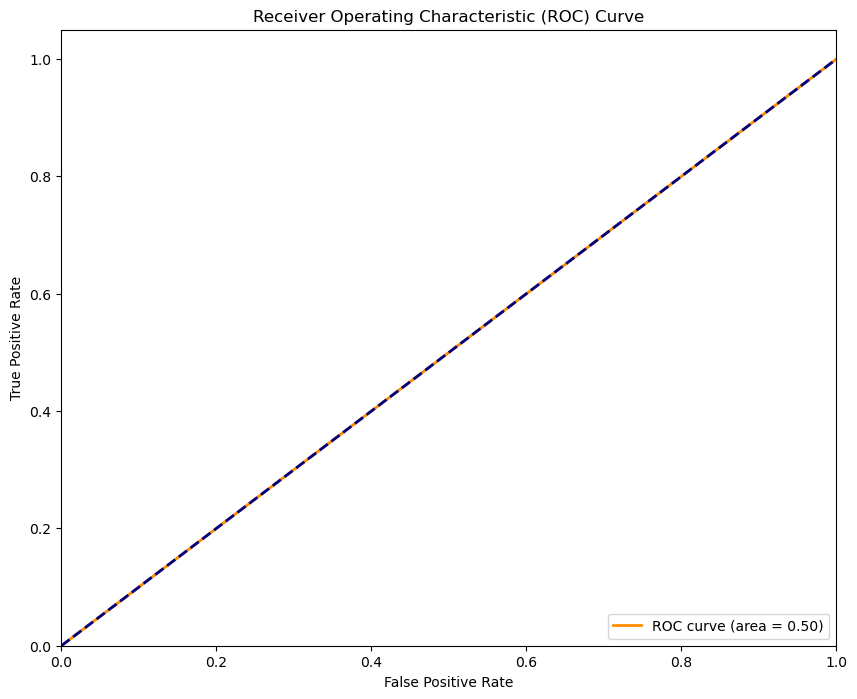

In [72]:
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

<h3>2. Random Forest Classifier</h3>

In [25]:
rf = RandomForestClassifier(labelCol="Is Laundering", featuresCol="scaledFeatures")
stages += [rf]
rf_pipeline = Pipeline(stages=stages)
(train, test) = data.randomSplit([0.5, 0.5], seed=42)
rf_model = rf_pipeline.fit(train)

<h4>Evaluation of Random Forest Classifer</h4>

In [27]:
rf_predictions = rf_model.transform(test)

evaluator = BinaryClassificationEvaluator(labelCol="Is Laundering")
accuracy = evaluator.evaluate(rf_predictions, {evaluator.metricName: "areaUnderROC"})
print(f"Area under ROC = {accuracy}")

Area under ROC = 0.5


In [28]:
evaluator = BinaryClassificationEvaluator(labelCol='Is Laundering', metricName='areaUnderROC')
roc_auc = evaluator.evaluate(rf_predictions)
print(f"ROC AUC: {roc_auc}")

evaluator_accuracy = MulticlassClassificationEvaluator(labelCol='Is Laundering', metricName='accuracy')
evaluator_precision = MulticlassClassificationEvaluator(labelCol='Is Laundering', metricName='weightedPrecision')
evaluator_recall = MulticlassClassificationEvaluator(labelCol='Is Laundering', metricName='weightedRecall')
evaluator_f1 = MulticlassClassificationEvaluator(labelCol='Is Laundering', metricName='f1')

accuracy = evaluator_accuracy.evaluate(rf_predictions)
precision = evaluator_precision.evaluate(rf_predictions)
recall = evaluator_recall.evaluate(rf_predictions)
f1_score = evaluator_f1.evaluate(rf_predictions)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1_score}")

ROC AUC: 0.5
Accuracy: 0.9988991193456477
Precision: 0.9977994506295105
Recall: 0.9988991193456477
F1 Score: 0.998348982169892


In [29]:
predictions_and_labels = rf_predictions.select('probability', 'Is Laundering').collect()

prob_positive = [row['probability'][1] for row in predictions_and_labels]
labels = [row['Is Laundering'] for row in predictions_and_labels]

In [30]:
fpr, tpr, thresholds = roc_curve(labels, prob_positive)
roc_auc = auc(fpr, tpr)

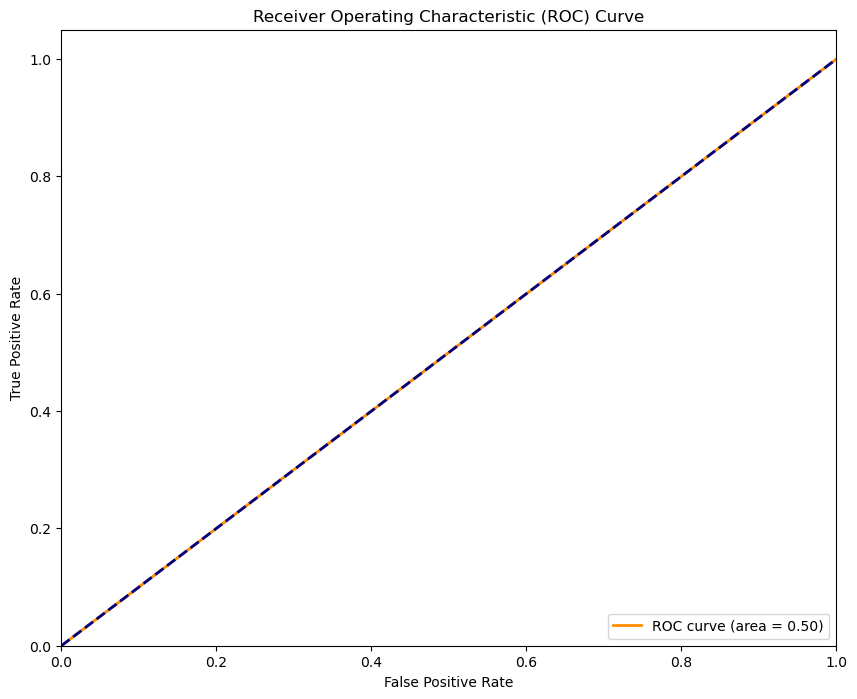

In [31]:
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()